اصايل حمدان حمود العصيمي


---


شعبة 2

In [1]:
# To process tabular data
import pandas as pd

# To perform mathematical operations
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# to Divide the data into training and test sets.
from sklearn.model_selection import train_test_split

# Scale numbers & encode categories
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import GridSearchCV

# cluster (KMeans) Model
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import linkage, fcluster,dendrogram

# SVM and SVC Model
from sklearn import svm
from sklearn.svm import SVC



# Evaluation Metrics for Models
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report,RocCurveDisplay
)



In [2]:
# Breast Cancer
# Step 1: Data Preprocessing
columns = [
    'ID', 'Diagnosis',
    'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean',
    'compactness_mean', 'concavity_mean', 'concave_points_mean', 'symmetry_mean', 'fractal_dimension_mean',
    'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
    'compactness_se', 'concavity_se', 'concave_points_se', 'symmetry_se', 'fractal_dimension_se',
    'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst',
    'compactness_worst', 'concavity_worst', 'concave_points_worst', 'symmetry_worst', 'fractal_dimension_worst'
]
# Load datasets.
data_df=pd.read_csv("/content/wdbc.data", names=columns)
# Show all columns
pd.set_option('display.max_columns', None)
# Show all rows
pd.set_option('display.max_rows', None)
# display the datasets
display(data_df)

,ID,Diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave_points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.990,10.38,122.80,1001.0,0.11840,0.27760,0.300100,0.147100,0.2419,0.07871,1.0950,0.9053,8.5890,153.400,0.006399,0.049040,0.053730,0.015870,0.030030,0.006193,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.711900,0.265400,0.4601,0.11890
1,842517,M,20.570,17.77,132.90,1326.0,0.08474,0.07864,0.086900,0.070170,0.1812,0.05667,0.5435,0.7339,3.3980,74.080,0.005225,0.013080,0.018600,0.013400,0.013890,0.003532,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.241600,0.186000,0.2750,0.08902
2,84300903,M,19.690,21.25,130.00,1203.0,0.10960,0.15990,0.197400,0.127900,0.2069,0.05999,0.7456,0.7869,4.5850,94.030,0.006150,0.040060,0.038320,0.020580,0.022500,0.004571,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.450400,0.243000,0.3613,0.08758
3,84348301,M,11.420,20.38,77.58,386.1,0.14250,0.28390,0.241400,0.105200,0.2597,0.09744,0.4956,1.1560,3.4450,27.230,0.009110,0.074580,0.056610,0.018670,0.059630,0.009208,14.910,26.50,98.87,567.7,0.20980,0.86630,0.686900,0.257500,0.6638,0.17300
4,84358402,M,20.290,14.34,135.10,1297.0,0.10030,0.13280,0.198000,0.104300,0.1809,0.05883,0.7572,0.7813,5.4380,94.440,0.011490,0.024610,0.056880,0.018850,0.017560,0.005115,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.400000,0.162500,0.2364,0.07678
5,843786,M,12.450,15.70,82.57,477.1,0.12780,0.17000,0.157800,0.080890,0.2087,0.07613,0.3345,0.8902,2.2170,27.190,0.007510,0.033450,0.036720,0.011370,0.021650,0.005082,15.470,23.75,103.40,741.6,0.17910,0.52490,0.535500,0.174100,0.3985,0.12440
6,844359,M,18.250,19.98,119.60,1040.0,0.09463,0.10900,0.112700,0.074000,0.1794,0.05742,0.4467,0.7732,3.1800,53.910,0.004314,0.013820,0.022540,0.010390,0.013690,0.002179,22.880,27.66,153.20,1606.0,0.14420,0.25760,0.378400,0.193200,0.3063,0.08368
7,84458202,M,13.710,20.83,90.20,577.9,0.11890,0.16450,0.093660,0.059850,0.2196,0.07451,0.5835,1.3770,3.8560,50.960,0.008805,0.030290,0.024880,0.014480,0.014860,0.005412,17.060,28.14,110.60,897.0,0.16540,0.36820,0.267800,0.155600,0.3196,0.11510
8,844981,M,13.000,21.82,87.50,519.8,0.12730,0.19320,0.185900,0.093530,0.2350,0.07389,0.3063,1.0020,2.4060,24.320,0.005731,0.035020,0.035530,0.012260,0.021430,0.003749,15.490,30.73,106.20,739.3,0.17030,0.54010,0.539000,0.206000,0.4378,0.10720
9,84501001,M,12.460,24.04,83.97,475.9,0.11860,0.23960,0.227300,0.085430,0.2030,0.08243,0.2976,1.5990,2.0390,23.940,0.007149,0.072170,0.077430,0.014320,0.017890,0.010080,15.090,40.68,97.65,711.4,0.18530,1.05800,1.105000,0.221000,0.4366,0.20750


In [3]:
# Step 1: Data Preprocessing

# Print missing values per column
print("Missing values in each column:")
print(data_df.isnull().sum())

# Check if there are any missing values
if data_df.isnull().sum().sum() == 0:
    print("\n No missing values found — Excellent!")
else:
    print("\n There are missing values — you need to handle them.")
print()


# Encode target variable
print("Target Variable Distribution:")
target_counts = data_df['Diagnosis'].value_counts()
print(target_counts)
data_df['Diagnosis_num'] = np.where(data_df['Diagnosis']=='M', 1, 0)

# Standardize numerical features

features = data_df.loc[:, ~data_df.columns.isin(['ID','Diagnosis','Diagnosis_num'])]
# Select target variable
target = data_df['Diagnosis_num']

# Standardize features to have mean=0 and std=1
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# split for supervised SVM only (70% training, 30% testing)
X_train, X_test, y_train, y_test = train_test_split(
    features_scaled, target, test_size=0.3, random_state=42, stratify=target
)

print("After preprocessing and splitting:")
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")

# Train SVM classifier (supervised learning)
clf = svm.SVC()
clf.fit(X_train, y_train)
score = clf.score(X_test, y_test)
print("SVM Accuracy on Test Set:", score)

# Apply K-Means clustering (unsupervised, no labels used)
kmeans = KMeans(n_clusters=2, random_state=42)
clusters_kmeans = kmeans.fit_predict(features_scaled)
print("K-Means Cluster Counts:", np.bincount(clusters_kmeans))

# Apply Hierarchical Clustering (unsupervised, no labels)
Z = linkage(features_scaled, method='ward')
clusters_hier = fcluster(Z, t=2, criterion='maxclust')
print("Hierarchical Cluster Counts:", np.bincount(clusters_hier))

Missing values in each column:
ID                         0
Diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave_points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave_points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave_points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

 No missing values found — 

In [4]:
# Step 2: Supervised Model Building

# Train Linear SVM
linear_svm = SVC(kernel='linear', C=1)
linear_svm.fit(X_train, y_train)
print("Linear SVM trained")

# Train RBF SVM
rbf_svm = SVC(kernel='rbf', C=1, gamma='scale')
rbf_svm.fit(X_train, y_train)
print("RBF SVM trained")

# Hyperparameter Tuning for RBF SVM
param_grid = {'C':[0.1, 1, 10], 'gamma':['scale', 0.01, 0.001]}
grid_search = GridSearchCV(SVC(kernel='rbf'), param_grid, cv=3)
grid_search.fit(X_train, y_train)
best_rbf_svm = grid_search.best_estimator_
print()

# Linear kernel used as baseline and RBF captures non-linear patterns
# basic hyperparameters C and gamma tuned via GridSearchCV to improve performance.


Linear SVM trained
RBF SVM trained



K-Means done
Hierarchical done


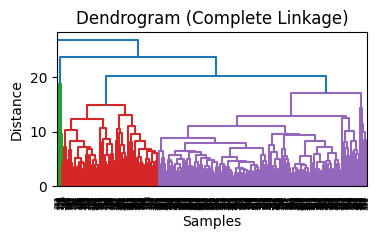

Clusters (K=2): [  0   2 567]


In [5]:
# Step 2: Unsupervised Model Building

# K-Means clustering
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(features_scaled)
print("K-Means done")

# Hierarchical clustering (single & complete linkage)
Z_single = linkage(features_scaled, method='single')
Z_complete = linkage(features_scaled, method='complete')
print("Hierarchical done")

# Dendrogram for complete linkage
plt.figure(figsize=(4, 2))
dendrogram(Z_complete)
plt.title("Dendrogram (Complete Linkage)")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

# Cut dendrogram to get 2 clusters
clusters_hier = fcluster(Z_complete, t=2, criterion='maxclust')
print("Clusters (K=2):", np.bincount(clusters_hier))

--- Linear SVM ---
Accuracy: 0.9649122807017544
Precision: 1.0
Recall: 0.90625
F1-Score: 0.9508196721311475
ROC-AUC: 0.953125
Confusion Matrix:
 [[107   0]
 [  6  58]]

--- Best RBF SVM ---
Accuracy: 0.9707602339181286
Precision: 0.9836065573770492
Recall: 0.9375
F1-Score: 0.96
ROC-AUC: 0.9640771028037383
Confusion Matrix:
 [[106   1]
 [  4  60]]



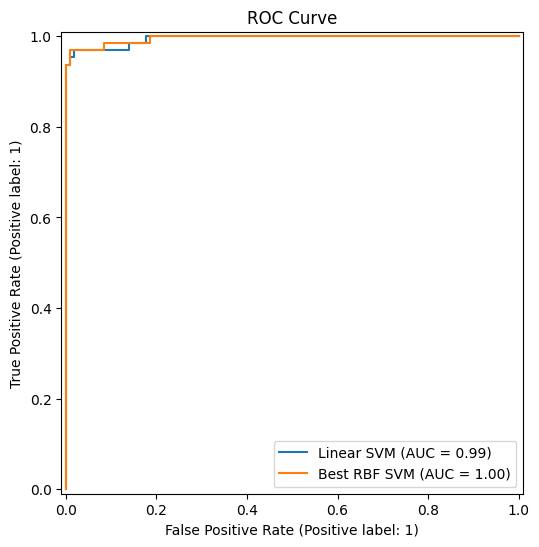

In [ ]:
# Step 3: SVM Evaluation and Visualization Supervised

# Predict labels
y_pred_linear = linear_svm.predict(X_test)
y_pred_rbf = best_rbf_svm.predict(X_test)

# Compute metrics and confusion matrix
def print_metrics(name, y_true, y_pred):
    print(f"--- {name} ---")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1-Score:", f1_score(y_true, y_pred))
    print("ROC-AUC:", roc_auc_score(y_true, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
    print()

print_metrics("Linear SVM", y_test, y_pred_linear)
print_metrics("Best RBF SVM", y_test, y_pred_rbf)

# Plot ROC curves
plt.figure(figsize=(8,6))
RocCurveDisplay.from_estimator(linear_svm, X_test, y_test, name="Linear SVM", ax=plt.gca())
RocCurveDisplay.from_estimator(best_rbf_svm, X_test, y_test, name="Best RBF SVM", ax=plt.gca())
plt.title("ROC Curve")
plt.show()

Silhouette Score K-Means: 0.3447344346611054
Silhouette Score Hierarchical: 0.6606668813897673
K-Means vs True Labels:
 Diagnosis_num    0    1
row_0                  
0               13  175
1              344   37
Hierarchical vs True Labels:
 Diagnosis_num    0    1
row_0                  
1                0    2
2              357  210


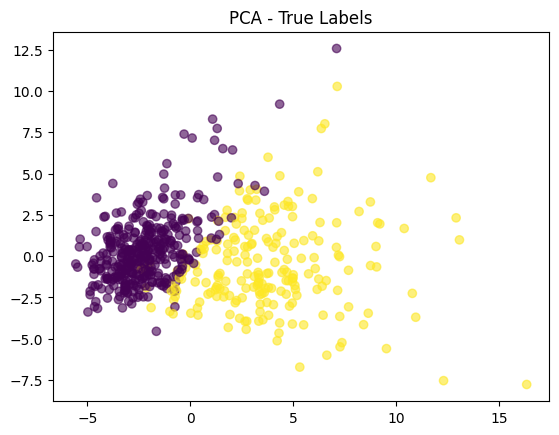

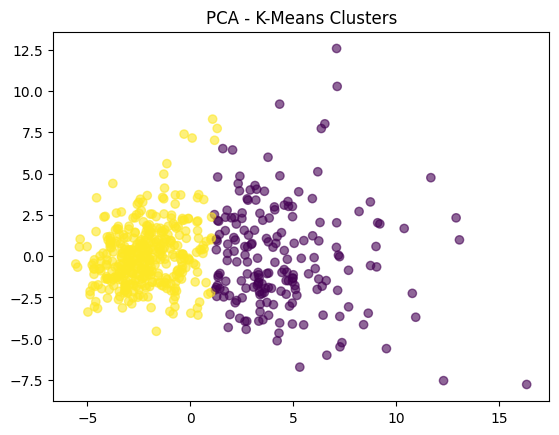

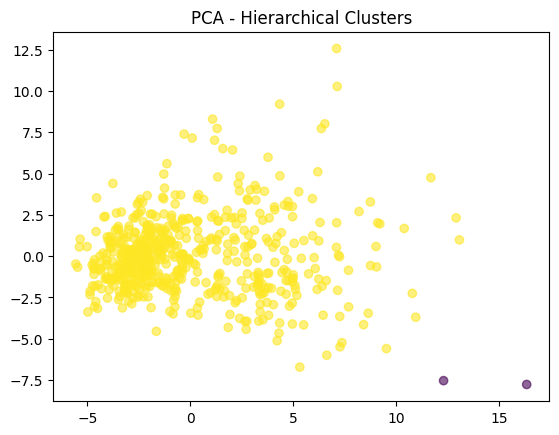

In [ ]:
# Step 3: Clustering Evaluation and Visualization Unsupervised
# Silhouette Scores
sil_kmeans = silhouette_score(features_scaled, kmeans.labels_)
sil_hier = silhouette_score(features_scaled, clusters_hier)
print("Silhouette Score K-Means:", sil_kmeans)
print("Silhouette Score Hierarchical:", sil_hier)

# Compare clusters to true labels
kmeans_table = pd.crosstab(kmeans.labels_, target)
hier_table = pd.crosstab(clusters_hier, target)
print("K-Means vs True Labels:\n", kmeans_table)
print("Hierarchical vs True Labels:\n", hier_table)

#  PCA for 2D visualization
pca = PCA(n_components=2)
features_2d = pca.fit_transform(features_scaled)

# Plot colored by true labels
plt.scatter(features_2d[:,0], features_2d[:,1], c=target, cmap='viridis', alpha=0.6)
plt.title("PCA - True Labels")
plt.show()

# Plot colored by K-Means clusters
plt.scatter(features_2d[:,0], features_2d[:,1], c=kmeans.labels_, cmap='viridis', alpha=0.6)
plt.title("PCA - K-Means Clusters")
plt.show()

# Plot colored by Hierarchical clusters
plt.scatter(features_2d[:,0], features_2d[:,1], c=clusters_hier, cmap='viridis', alpha=0.6)
plt.title("PCA - Hierarchical Clusters")
plt.show()



# Step 4: Comparative Analysis
1- How does SVM performance compare to K-Means and Hierarchical?


---

With accuracy over 96% and robust Precision, Recall, and ROC-AUC scores, the SVM models (both Linear and RBF) performed quite well. This is to be expected as SVM is a supervised learning technique that learns distinct boundaries between benign and malignant instances by using the actual class labels during training.

However, the unsupervised models (K-Means and Hierarchical Clustering) do not know the true labels; instead, they rely solely on feature similarity. Their performance suffered as a result, particularly K-Means, which considerably mixed the two classes. The greater Silhouette Score of Hierarchical Clustering indicates that it performed comparatively better.

2- Which method seems to separate the classes better, and why?


---

Compared to K-Means and Hierarchical, which only rely on feature similarity, SVM achieves superior accuracy and cleaner class boundaries because it is a supervised method that employs the true labels.

3- How did preprocessing (encoding, scaling) help your models?

---
The diagnosis labels were transformed into numerical form (0/1) by encoding the target, which is necessary for SVM and quantitative assessment.

All features have a mean of 0 and a standard deviation of 1 thanks to scaling (standardisation), which prevents features with wide numerical ranges from taking precedence over those with narrow ranges. This facilitates the fair treatment of all features by both SVM and clustering.

Proper preprocessing allowed SVM to achieve stable classification and good accuracy.  Although clustering is still less effective than supervised learning, clustering (K-Means/Hierarchical) also had a clearer feature space to group.




4- which method (SVM, K-Means, Hierarchical) would you recommend, and why?

---
I would recommend SVM,
because it is a supervised method that learns the true class boundaries. It achieved much higher accuracy and stronger evaluation metrics compared to K-Means and Hierarchical Clustering, which struggled since they do not use the real labels.